# Building A WaveNet To Predict Next Char In A Sequence

In [148]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [149]:
# read the dataset (names.txt)
words = open('names.txt', 'r').read().splitlines()

In [150]:
chars = sorted(list(set('.abcdefghijklmnopqrstuvwxyz')))
chartoi = {s:i for i, s in enumerate(chars)}
itochar = {i:s for s,i in chartoi.items()}

In [151]:
# build the dataset

block_size = 8 # Defines the context length ie. how many characters to use to predict the next one
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        idx = chartoi[ch]
        X.append(context)
        Y.append(idx)
        #print(f"{"".join(itochar[c] for c in context)} --> {ch}")
        context = context[1:] + [idx] # pop and push

X = torch.tensor(X)
Y = torch.tensor(Y)

In [154]:
# split the data into training, validation, and test set

N = X.shape[0] 
n_train = int(0.8 * N)
n_val = int(0.1 * N)
# n_test is whatever is left over

indices = torch.randperm(N)

train_indices = indices[:n_train]
val_indices = indices[n_train : n_train + n_val]
test_indices = indices[n_train + n_val:]

X_train, Y_train = X[train_indices], Y[train_indices]
X_val, Y_val = X[val_indices], Y[val_indices]
X_test, Y_test = X[test_indices], Y[test_indices]

print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Val:   {X_val.shape}, {Y_val.shape}")
print(f"Test:  {X_test.shape}, {Y_test.shape}")

Train: torch.Size([182516, 8]), torch.Size([182516])
Val:   torch.Size([22814, 8]), torch.Size([22814])
Test:  torch.Size([22816, 8]), torch.Size([22816])


In [210]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # Kaiming init
        self.bias = torch.randn(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
  
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        B, T, C = x.shape
        
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [225]:
torch.manual_seed(42);

In [226]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP
vocab_size = len(chars)

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # make last later less confident

print(f"Total number of parameters: {sum(p.nelement() for p in model.parameters())}")

for p in model.parameters():
    p.requires_grad = True

Total number of parameters: 22397


In [227]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  1, 13,  9],
        [ 0,  2, 18,  5, 24, 12,  5,  5],
        [ 0,  0,  0,  0,  0,  0, 11, 25]])

In [228]:
for i in range(len(model.layers)):
    print(f"{i:2d}) {model.layers[i].__class__.__name__:20s}:  shape = {str(model.layers[i].out.shape):25s}| params = {sum(p.nelement() for p in model.layers[i].parameters())}")

 0) Embedding           :  shape = torch.Size([4, 8, 10])   | params = 270
 1) FlattenConsecutive  :  shape = torch.Size([4, 4, 20])   | params = 0
 2) Linear              :  shape = torch.Size([4, 4, 68])   | params = 1360
 3) BatchNorm1d         :  shape = torch.Size([4, 4, 68])   | params = 136
 4) Tanh                :  shape = torch.Size([4, 4, 68])   | params = 0
 5) FlattenConsecutive  :  shape = torch.Size([4, 2, 136])  | params = 0
 6) Linear              :  shape = torch.Size([4, 2, 68])   | params = 9248
 7) BatchNorm1d         :  shape = torch.Size([4, 2, 68])   | params = 136
 8) Tanh                :  shape = torch.Size([4, 2, 68])   | params = 0
 9) FlattenConsecutive  :  shape = torch.Size([4, 136])     | params = 0
10) Linear              :  shape = torch.Size([4, 68])      | params = 9248
11) BatchNorm1d         :  shape = torch.Size([4, 68])      | params = 136
12) Tanh                :  shape = torch.Size([4, 68])      | params = 0
13) Linear              :  shape =

In [234]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [229]:
max_steps = 200000
batch_size = 32
lossi = []

for layer in model.layers:
    layer.training = True

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in model.parameters():
        p.grad = None
    loss.backward()

    # update: Simple SGD
    lr = 0.1 if i < 100000 else 0.01
    for p in model.parameters():
        p.data -= lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

      0/ 200000: 3.9488
  10000/ 200000: 2.1782
  20000/ 200000: 1.9578
  30000/ 200000: 2.1745
  40000/ 200000: 1.8527
  50000/ 200000: 2.2206
  60000/ 200000: 1.9846
  70000/ 200000: 1.6847
  80000/ 200000: 2.0057
  90000/ 200000: 1.7823
 100000/ 200000: 2.2219
 110000/ 200000: 2.1835
 120000/ 200000: 1.7422
 130000/ 200000: 1.8948
 140000/ 200000: 2.3400
 150000/ 200000: 1.6154
 160000/ 200000: 1.9767
 170000/ 200000: 2.2547
 180000/ 200000: 1.9213
 190000/ 200000: 1.6783


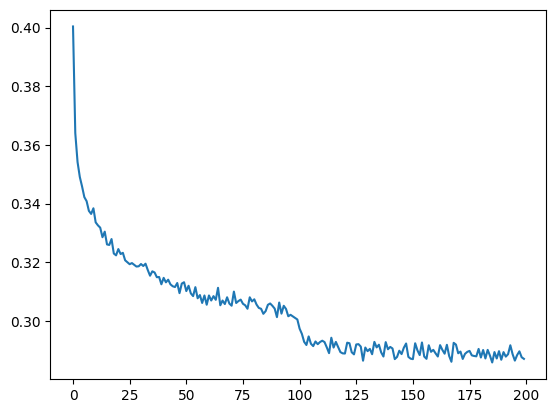

In [230]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [231]:
# put layers into eval mode
for layer in model.layers:
    layer.training = False

In [232]:
# Evaluate loss on train, val, and test sets

@torch.no_grad() # disable gradient tracking
def split_loss(split):
    x,y = {
        "train": (X_train, Y_train),
        "val": (X_val, Y_val),
        "test": (X_test, Y_test)
    }[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    
    print(f"{split:6s}: {loss.data:.4f}")

split_loss("train")
split_loss("val")
split_loss("test")

train : 1.9245
val   : 2.0260
test  : 2.0143


### Performance Log:

- **MLP /w block size = 3 (12k params)**
    - train: 2.0665
    - val: 2.1181
- **MLP /w block size = 8 (22k params)**
    - train: 1.9323
    - val: 2.0276
- **Wavenet /w block size = 8**
    - train: 1.9245
    - test: 2.0260

In [237]:
# Use the model to generate new sequences

# put layers into eval mode (just be sure)
for layer in model.layers:
    layer.training = False

for _ in range(10):
    seq = "."*block_size
    
    while True:
        # build model input
        inp = torch.tensor([[chartoi[s] for s in seq[-block_size:]]])

        # forward pass
        logits = model(inp)
        next_char_probs = F.softmax(logits, dim=1)

        # identify next char based on model probs
        next_char_i = torch.multinomial(next_char_probs, 1, replacement=True)
        next_char = itochar[next_char_i[0][0].item()]

        # append to sequence
        seq += next_char
        if next_char == '.':
            break
    
    print(seq[block_size:])

ra.
nierna.
ashawn.
olhien.
torry.
kienna.
bihiah.
thele.
trishya.
dizalie.
